# Studio Ghibli v. OpenAI
### CPSC 184 Final Project: Ghibli Style Detector
#### Vinh Tran

#### References
- Sora (AI Gen Images)
- https://huggingface.co/blog/LLMhacker/ghibli-ai-image (2 images)
- Real Images: https://www.ghibli.jp/works/


## Setup

### Installation

In [2]:
def detect_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

ON_COLAB = detect_colab()
print(f"Running on Colab: {ON_COLAB}")

Running on Colab: False


In [3]:
if ON_COLAB:
  from google.colab import drive
  drive.mount('/content/drive', force_remount=True)
  !pip install git+https://github.com/openai/CLIP.git # run once

### Import

In [4]:
import os
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import clip
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Path Setup

In [24]:
# Define consistent relative pathing
ROOT_DATA_PATH = "/content/drive/MyDrive/Senior/Sem 2/Digital IP/final project/ghibli_data" if ON_COLAB else "./ghibli_data"
ROOT_RESULTS_PATH = "/content/drive/MyDrive/Senior/Sem 2/Digital IP/final project/results" if ON_COLAB else "./results"
REAL_FOLDER = os.path.join(ROOT_DATA_PATH, "ghibli_real")
AI_FOLDER = os.path.join(ROOT_DATA_PATH, "ghibli_ai")
OUTPUT_PATH = os.path.join(ROOT_RESULTS_PATH, "similarity_results.csv")
OUTPUT_PLOT_PATH = os.path.join(ROOT_RESULTS_PATH, "similarity_scatter.png")
print(os.listdir(ROOT_DATA_PATH))
print(os.listdir(REAL_FOLDER))
print(os.listdir(AI_FOLDER))

['ghibli_real', 'ghibli_ai']
['ghibli_09.png', 'ghibli_08.png', 'ghibli_01.png', 'ghibli_03.png', 'ghibli_02.png', 'ghibli_06.png', 'ghibli_07.png', 'ghibli_05.png', 'ghibli_10.png', 'ghibli_04.png']
['ai_08.png', 'ai_09.png', 'ai_01.png', 'ai_02.png', 'ai_03.png', 'ai_07.png', 'ai_06.png', 'ai_10.png', 'ai_04.png', 'ai_05.png']


### Config

In [16]:
# ================================
#        CONFIG
# ================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize(224),                  # Resize shortest side to 224
    transforms.CenterCrop(224),              # Crop center square
    transforms.ToTensor(),                   # Convert to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],           # Standard ImageNet means
        std=[0.229, 0.224, 0.225]             # Standard ImageNet stds
    )
])

## STYLE: VGG + Gram Matrices

In [17]:
# ================================
#     STYLE: VGG + Gram Matrices
# ================================

class StyleExtractor(torch.nn.Module):
    def __init__(self, selected_layers=None):
        super().__init__()
        self.model = models.vgg19(pretrained=True).features[:21].to(DEVICE).eval()
        self.selected_layers = selected_layers or ['0', '5', '10', '19']

    def forward(self, x):
        features = {}
        for name, layer in self.model._modules.items():
            x = layer(x)
            if name in self.selected_layers:
                features[name] = x
        return features

def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    features = tensor.view(b, c, h * w)
    G = torch.bmm(features, features.transpose(1, 2))
    return G / (c * h * w)

def compute_style_distance(img1, img2, extractor):
    feats1 = extractor(img1)
    feats2 = extractor(img2)
    distance = 0.0
    for layer in feats1:
        gram1 = gram_matrix(feats1[layer])
        gram2 = gram_matrix(feats2[layer])
        distance += torch.nn.functional.mse_loss(gram1, gram2)
    return distance.item()

## SEMANTIC: CLIP Similarity

In [18]:
# ================================
#     SEMANTIC: CLIP Similarity
# ================================

def load_clip_model():
    model, preprocess = clip.load("ViT-B/32", device=DEVICE)
    return model, preprocess

def compute_clip_similarity(img1, img2, model, preprocess):
    with torch.no_grad():
        img1_embed = model.encode_image(preprocess(img1).unsqueeze(0).to(DEVICE))
        img2_embed = model.encode_image(preprocess(img2).unsqueeze(0).to(DEVICE))
        img1_embed /= img1_embed.norm(dim=-1, keepdim=True)
        img2_embed /= img2_embed.norm(dim=-1, keepdim=True)
        similarity = (img1_embed @ img2_embed.T).item()
    return similarity

##  Categorization Functions (Helper)

In [19]:
# ================================
# Categorization Functions (Helper)
# ================================
# Thresholds
STYLE_HIGH = 0.00015
STYLE_MED = 0.00025
SEM_HIGH = 0.85
SEM_MED = 0.70

def categorize_style(val):
    if val <= STYLE_HIGH:
        return "High"
    elif val <= STYLE_MED:
        return "Medium"
    else:
        return "Low"

def categorize_semantic(val):
    if val >= SEM_HIGH:
        return "High"
    elif val >= SEM_MED:
        return "Medium"
    else:
        return "Low"

def risk_zone(style, semantic):
    if style == "High" and semantic == "High":
        return "High Risk"
    elif style == "High" or semantic == "High":
        return "Possibly Derivative"
    elif style == "Medium" and semantic == "Medium":
        return "Possibly Derivative"
    elif style == "Medium" or semantic == "Medium":
        return "Gray Area"
    else:
        return "Safe Zone"
    

def expression_vs_idea(style_sim, sem_sim, style_thresh=STYLE_HIGH, sem_thresh=SEM_HIGH):
    if style_sim > style_thresh and sem_sim >= sem_thresh:
        return "Same Idea, Different Expression"
    elif style_sim <= style_thresh and sem_sim < sem_thresh:
        return "Same Expression, Different Idea"
    elif style_sim <= style_thresh and sem_sim >= sem_thresh:
        return "Same Expression, Same Idea"
    else:
        return "Different Expression and Idea"

## IMAGE I/O AND PROCESSING

In [20]:
# ================================
#     IMAGE I/O AND PROCESSING
# ================================

def load_image(path, for_clip=False):
    img = Image.open(path).convert("RGB")
    return img if for_clip else transform(img).unsqueeze(0).to(DEVICE)

def batch_compare(real_dir, ai_dir):
    vgg = StyleExtractor()
    clip_model, clip_preprocess = load_clip_model()

    results = []

    real_images = sorted([f for f in os.listdir(real_dir) if f.endswith(('.png', '.jpg'))])
    ai_images = sorted([f for f in os.listdir(ai_dir) if f.endswith(('.png', '.jpg'))])

    real_tensors = {f: load_image(os.path.join(real_dir, f)) for f in real_images}
    real_clip = {f: load_image(os.path.join(real_dir, f), for_clip=True) for f in real_images}

    for ai_file in tqdm(ai_images, desc="Processing AI Images"):
        ai_path = os.path.join(ai_dir, ai_file)
        ai_tensor = load_image(ai_path)
        ai_clip_img = load_image(ai_path, for_clip=True)

        # STYLE SIMILARITY
        style_scores = []
        for real_file, real_tensor in real_tensors.items():
            score = compute_style_distance(ai_tensor, real_tensor, vgg)
            style_scores.append((real_file, score))
        style_scores.sort(key=lambda x: x[1])
        avg_style_score = np.mean([s for _, s in style_scores])
        top3_style = [f"{fname} ({dist:.4f})" for fname, dist in style_scores[:3]]
        style_cat = categorize_style(avg_style_score)

        # SEMANTIC SIMILARITY
        sem_scores = []
        for real_file, real_img in real_clip.items():
            score = compute_clip_similarity(ai_clip_img, real_img, clip_model, clip_preprocess)
            sem_scores.append((real_file, score))
        sem_scores.sort(key=lambda x: x[1], reverse=True)
        max_semantic_score = sem_scores[0][1]
        top3_semantic = [f"{fname} ({sim:.4f})" for fname, sim in sem_scores[:3]]
        semantic_cat = categorize_semantic(max_semantic_score)

        # RISK ZONE
        risk = risk_zone(style_cat, semantic_cat)
        expr_idea = expression_vs_idea(avg_style_score, max_semantic_score)

        results.append({
            "ai_image": ai_file,
            "style_distance_avg": avg_style_score,
            "semantic_similarity_max": max_semantic_score,
            "top3_style_matches": ", ".join(top3_style),
            "top3_semantic_matches": ", ".join(top3_semantic),
            "style_category": style_cat,
            "semantic_category": semantic_cat,
            "risk_label": risk,
            "expression_vs_idea": expr_idea
        })

    return results

## Driver

In [21]:
results = batch_compare(REAL_FOLDER, AI_FOLDER)
df = pd.DataFrame(results)
df.to_csv(OUTPUT_PATH, index=False)
print(f"\nResults saved to {OUTPUT_PATH}")

/Users/vinhtran/Desktop/ghibli/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/vinhtran/Desktop/ghibli/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Processing AI Images: 100%|██████████| 10/10 [00:15<00:00,  1.54s/it]


Results saved to ./results/similarity_results.csv


In [25]:
df.head()

,ai_image,style_distance_avg,semantic_similarity_max,top3_style_matches,top3_semantic_matches,style_category,semantic_category,risk_label,expression_vs_idea
0,ai_01.png,0.000158,0.715895,"ghibli_09.png (0.0001), ghibli_02.png (0.0001)...","ghibli_09.png (0.7159), ghibli_05.png (0.6987)...",Medium,Medium,Possibly Derivative,Different Expression and Idea
1,ai_02.png,0.000137,0.673683,"ghibli_10.png (0.0001), ghibli_02.png (0.0001)...","ghibli_02.png (0.6737), ghibli_07.png (0.6603)...",High,Low,Possibly Derivative,"Same Expression, Different Idea"
2,ai_03.png,0.000180,0.805443,"ghibli_10.png (0.0001), ghibli_07.png (0.0001)...","ghibli_03.png (0.8054), ghibli_02.png (0.5750)...",Medium,Medium,Possibly Derivative,Different Expression and Idea
3,ai_04.png,0.000242,0.792543,"ghibli_09.png (0.0001), ghibli_05.png (0.0002)...","ghibli_04.png (0.7925), ghibli_05.png (0.7593)...",Medium,Medium,Possibly Derivative,Different Expression and Idea
4,ai_05.png,0.000116,0.802489,"ghibli_02.png (0.0001), ghibli_09.png (0.0001)...","ghibli_05.png (0.8025), ghibli_06.png (0.7715)...",High,Medium,Possibly Derivative,"Same Expression, Different Idea"


## Plotting

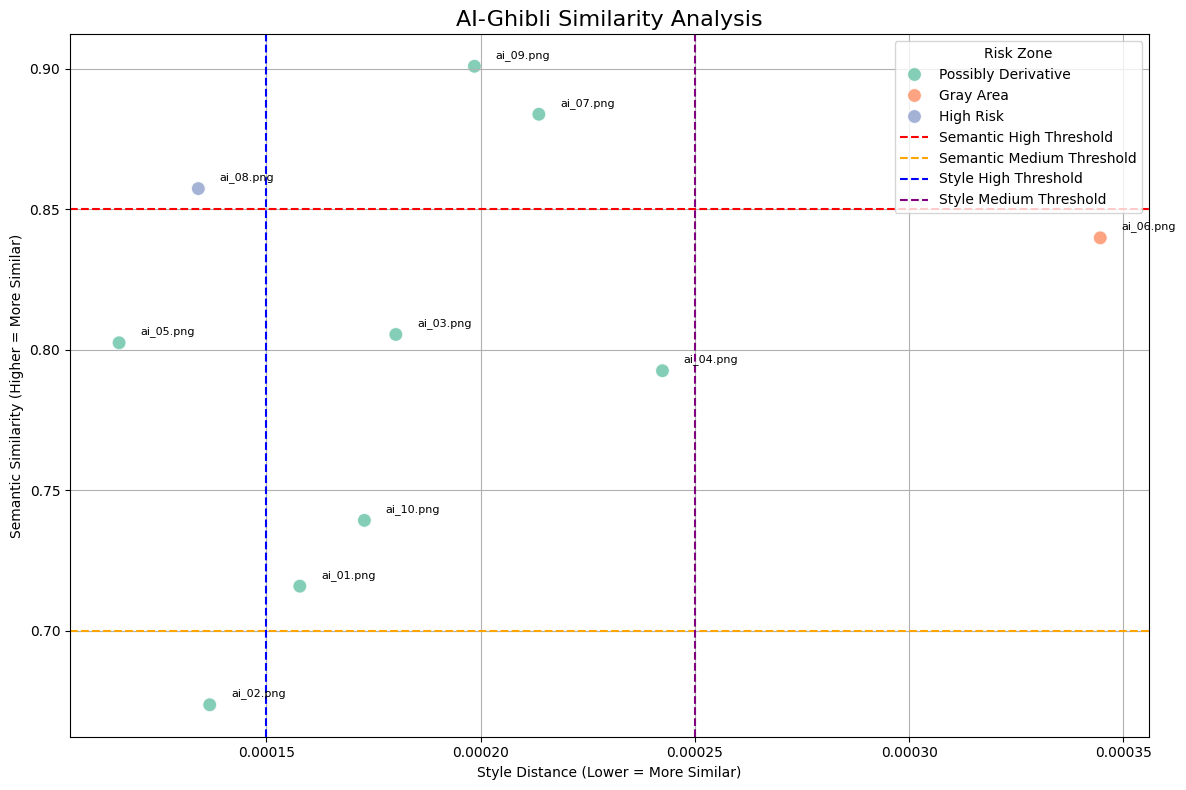

In [29]:
# Create scatter plot with labels
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x="style_distance_avg",
    y="semantic_similarity_max",
    hue="risk_label",
    palette="Set2",
    s=100,
    alpha=0.8
)

# Add horizontal threshold lines (semantic similarity)
plt.axhline(y=SEM_HIGH, color='red', linestyle='--', label='Semantic High Threshold')
plt.axhline(y=SEM_MED, color='orange', linestyle='--', label='Semantic Medium Threshold')

# Add vertical threshold lines (style distance)
plt.axvline(x=STYLE_HIGH, color='blue', linestyle='--', label='Style High Threshold')
plt.axvline(x=STYLE_MED, color='purple', linestyle='--', label='Style Medium Threshold')

# Add image labels
for i in range(df.shape[0]):
    plt.text(
        df["style_distance_avg"][i] + 0.000005,
        df["semantic_similarity_max"][i] + 0.003,
        df["ai_image"][i],
        fontsize=8
    )

plt.title("AI-Ghibli Similarity Analysis", fontsize=16)
plt.xlabel("Style Distance (Lower = More Similar)")
plt.ylabel("Semantic Similarity (Higher = More Similar)")
plt.grid(True)
plt.legend(title="Risk Zone", loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_PLOT_PATH)
plt.show()